In [8]:
import torch
import os

dir_loaders = 'dataloaders'
rock_loader = torch.load(os.path.join(dir_loaders, 'rock_dataloader_zeros.pt'), weights_only=False)
paper_loader = torch.load(os.path.join(dir_loaders, 'paper_dataloader_zeros.pt'), weights_only=False)
scissor_loader = torch.load(os.path.join(dir_loaders, 'scissor_dataloader_zeros.pt'), weights_only=False)

all_rocks = []
for x, y in rock_loader:
    all_rocks.append(x[y==1])
all_rocks = torch.cat(all_rocks, dim=0)

all_papers = []
for x, y in paper_loader:
    all_papers.append(x[y==1])
all_papers = torch.cat(all_papers, dim=0)

all_scissors = []
for x, y in scissor_loader:
    all_scissors.append(x[y==1])
all_scissors = torch.cat(all_scissors, dim=0)

print(all_rocks.shape)
print(all_papers.shape)
print(all_scissors.shape)

torch.Size([296, 1, 8, 400])
torch.Size([296, 1, 8, 400])
torch.Size([296, 1, 8, 400])


In [9]:
import torch
import numpy as np
import pywt
from scipy.signal import welch
import os

# ---------- Feature functions ----------
def rms(signal):
    return np.sqrt(np.mean(signal**2))

def waveform_length(signal):
    return np.sum(np.abs(np.diff(signal)))

def zero_crossings(signal, threshold=0.01):
    # Count sign changes with threshold
    return np.sum(((signal[:-1] * signal[1:]) < 0) &
                  (np.abs(signal[:-1] - signal[1:]) > threshold))

def slope_sign_changes(signal, threshold=0.01):
    # Detect slope sign changes
    diff = np.diff(signal)
    return np.sum(((diff[:-1] * diff[1:]) < 0) &
                  (np.abs(diff[:-1] - diff[1:]) > threshold))

def median_freq(signal, fs=1000):  # <-- adjust fs if known
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    cumulative = np.cumsum(psd)
    cutoff = cumulative[-1] / 2
    return freqs[np.where(cumulative >= cutoff)[0][0]]

def sample_entropy(signal, m=2, r=0.2):
    # Approximate sample entropy
    N = len(signal)
    r *= np.std(signal)
    
    def _phi(m):
        x = np.array([signal[i:i+m] for i in range(N - m + 1)])
        C = np.sum(np.sum(np.abs(x[:,None] - x[None,:]), axis=2) <= r, axis=0) - 1
        return np.sum(C) / ((N - m + 1) * (N - m))
    
    ratio = _phi(m+1) / (_phi(m) + 1e-12)
    ratio = np.clip(ratio, 1e-12, None)
    return -np.log(ratio)

def shannon_entropy(signal, bins=30):
    hist, _ = np.histogram(signal, bins=bins, density=True)
    hist = np.clip(hist, 1e-12, None)
    return -np.sum(hist * np.log2(hist))

def wavelet_energy(signal, wavelet='db4', level=3):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    energies = [np.sum(np.square(c)) for c in coeffs]
    return np.sum(energies)

def higuchi_fd(signal, kmax=10):
    # Higuchi fractal dimension
    N = len(signal)
    L = []
    x = signal
    for k in range(1, kmax+1):
        Lk = []
        for m in range(k):
            idx = np.arange(m, N, k)
            Lm = np.sum(np.abs(np.diff(x[idx]))) * (N-1)/(((N-m)//k) * k)
            Lk.append(Lm)
        L.append(np.mean(Lk))
    L = np.log(np.clip(L, 1e-12, None))
    ln_k = np.log(np.clip(1.0/np.arange(1, kmax+1), 1e-12, None))
    return -np.polyfit(ln_k, L, 1)[0]

# ---------- Main extractor ----------
def extract_emg_features(emg_tensor, fs=1000):
    """
    emg_tensor: torch.Size([samples, 1, channels, timesteps])
    Returns: numpy array of shape [samples, channels * n_features]
    """
    emg_np = emg_tensor.squeeze(1).numpy()  # shape: [samples, channels, timesteps]
    n_samples, n_channels, n_timesteps = emg_np.shape
    
    features = []
    for s in range(n_samples):
        sample_feats = []
        for ch in range(n_channels):
            sig = emg_np[s, ch, :]
            
            feats = [
                rms(sig),
                waveform_length(sig),
                zero_crossings(sig),
                slope_sign_changes(sig),
                median_freq(sig, fs),
                sample_entropy(sig),
                shannon_entropy(sig),
                wavelet_energy(sig),
                higuchi_fd(sig),
            ]
            sample_feats.extend(feats)
        features.append(sample_feats)
    
    return np.array(features)

# ---------- Example usage ----------
if __name__ == "__main__":
    dir_loaders = 'dataloaders'
    types = ['rock', 'paper', 'scissor']

    feature_data = {}

    for _type in types:
        print(f'Processing {_type} data...')
        loader = torch.load(os.path.join(dir_loaders, f'{_type}_dataloader_zeros.pt'), weights_only=False)

        # Load data
        all_x = []
        for x, y in loader:
            all_x.append(x[y==1])
        all_x = torch.cat(all_x, dim=0)

        X_feats = extract_emg_features(all_x, fs=100)
        print("Feature matrix shape:", X_feats.shape)

        feature_data[_type] = X_feats



Processing rock data...
Feature matrix shape: (296, 72)
Processing paper data...
Feature matrix shape: (296, 72)
Processing scissor data...
Feature matrix shape: (296, 72)


Paper vs Scissor: 0.9453809908718875
Rock vs Scissor: 12.936071846466302
Rock vs Paper: 10.888213461060227


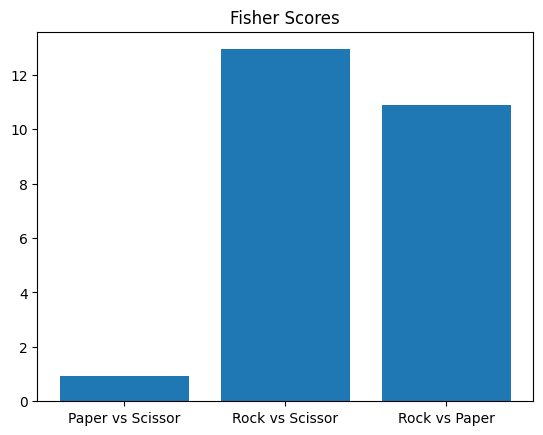

In [10]:
def compute_fisher_scores(data1, data2):
    m1 = np.mean(data1, axis=0)
    m2 = np.mean(data2, axis=0)
    v1 = np.var(data1, axis=0, ddof=0)
    v2 = np.var(data2, axis=0, ddof=0)
    scores = (m1 - m2)**2 / (v1 + v2 + 1e-12)
    return np.max(scores)

paper_scissor = compute_fisher_scores(feature_data["paper"], feature_data["scissor"])
rock_scissor = compute_fisher_scores(feature_data["rock"], feature_data["scissor"])
rock_paper = compute_fisher_scores(feature_data["rock"], feature_data["paper"])

print(f"Paper vs Scissor: {paper_scissor}")
print(f"Rock vs Scissor: {rock_scissor}")
print(f"Rock vs Paper: {rock_paper}")

import matplotlib.pyplot as plt

plt.bar(x=["Paper vs Scissor", "Rock vs Scissor", "Rock vs Paper"], height=[paper_scissor, rock_scissor, rock_paper])
plt.title("Fisher Scores")
plt.show()

In [11]:
# Sensor Importance Analysis
# This analysis shows which sensors have the most impact on classification performance
# by systematically zeroing out individual sensors and measuring the change in Fisher scores

def analyze_sensor_importance(class1_data, class2_data, class1_name, class2_name):
    """
    Analyze sensor importance by zeroing out individual sensors and computing Fisher scores
    
    Args:
        class1_data: tensor of shape [samples, 1, 8, 400] for first class
        class2_data: tensor of shape [samples, 1, 8, 400] for second class
        class1_name: name of first class
        class2_name: name of second class
    
    Returns:
        result_matrix: 8x8 matrix of Fisher scores when sensors are zeroed out
    """
    n_sensors = 8
    result_matrix = np.zeros((n_sensors, n_sensors))
    
    print(f"Analyzing sensor importance for {class1_name} vs {class2_name}...")
    
    for i in range(n_sensors):
        # Zero out sensor i in class1
        class1_modified = class1_data.clone()
        class1_modified[:, :, i, :] = 0
        
        for j in range(n_sensors):
            # Zero out sensor j in class2
            class2_modified = class2_data.clone()
            class2_modified[:, :, j, :] = 0
            
            # Extract features from modified data
            class1_features = extract_emg_features(class1_modified, fs=100)
            class2_features = extract_emg_features(class2_modified, fs=100)
            
            # Compute Fisher score
            fisher_score = compute_fisher_scores(class1_features, class2_features)
            result_matrix[i, j] = fisher_score
            
            print(f"  Sensor {i+1} ({class1_name}) + Sensor {j+1} ({class2_name}) zeroed: F-score = {fisher_score:.4f}")
    
    return result_matrix

# Perform sensor importance analysis for all class combinations
print("=" * 60)
print("SENSOR IMPORTANCE ANALYSIS")
print("=" * 60)

# Rock vs Scissor analysis
rock_scissor_matrix = analyze_sensor_importance(all_rocks, all_scissors, "Rock", "Scissor")

print("\n" + "=" * 60)
print("Rock vs Scissor Sensor Importance Matrix")
print("Rows: Rock sensors zeroed, Columns: Scissor sensors zeroed")
print("=" * 60)
print(rock_scissor_matrix)


SENSOR IMPORTANCE ANALYSIS
Analyzing sensor importance for Rock vs Scissor...
  Sensor 1 (Rock) + Sensor 1 (Scissor) zeroed: F-score = 1.2336
  Sensor 1 (Rock) + Sensor 2 (Scissor) zeroed: F-score = 13649.9327
  Sensor 1 (Rock) + Sensor 3 (Scissor) zeroed: F-score = 4448.4076
  Sensor 1 (Rock) + Sensor 4 (Scissor) zeroed: F-score = 18538.1839
  Sensor 1 (Rock) + Sensor 5 (Scissor) zeroed: F-score = 21652.4148
  Sensor 1 (Rock) + Sensor 6 (Scissor) zeroed: F-score = 12712.4098
  Sensor 1 (Rock) + Sensor 7 (Scissor) zeroed: F-score = 2642.3638
  Sensor 1 (Rock) + Sensor 8 (Scissor) zeroed: F-score = 9137.9205
  Sensor 2 (Rock) + Sensor 1 (Scissor) zeroed: F-score = 7750.9638
  Sensor 2 (Rock) + Sensor 2 (Scissor) zeroed: F-score = 12.9361
  Sensor 2 (Rock) + Sensor 3 (Scissor) zeroed: F-score = 4448.4076
  Sensor 2 (Rock) + Sensor 4 (Scissor) zeroed: F-score = 18538.1839
  Sensor 2 (Rock) + Sensor 5 (Scissor) zeroed: F-score = 21652.4148
  Sensor 2 (Rock) + Sensor 6 (Scissor) zeroed: F-s

In [12]:
# Paper vs Scissor analysis
paper_scissor_matrix = analyze_sensor_importance(all_papers, all_scissors, "Paper", "Scissor")

print("\n" + "=" * 60)
print("Paper vs Scissor Sensor Importance Matrix")
print("Rows: Paper sensors zeroed, Columns: Scissor sensors zeroed")
print("=" * 60)
print(paper_scissor_matrix)


Analyzing sensor importance for Paper vs Scissor...
  Sensor 1 (Paper) + Sensor 1 (Scissor) zeroed: F-score = 0.9454
  Sensor 1 (Paper) + Sensor 2 (Scissor) zeroed: F-score = 12444.2575
  Sensor 1 (Paper) + Sensor 3 (Scissor) zeroed: F-score = 5253.2660
  Sensor 1 (Paper) + Sensor 4 (Scissor) zeroed: F-score = 8560.4365
  Sensor 1 (Paper) + Sensor 5 (Scissor) zeroed: F-score = 5148.3686
  Sensor 1 (Paper) + Sensor 6 (Scissor) zeroed: F-score = 1892.4830
  Sensor 1 (Paper) + Sensor 7 (Scissor) zeroed: F-score = 1892.4830
  Sensor 1 (Paper) + Sensor 8 (Scissor) zeroed: F-score = 5577.8524
  Sensor 2 (Paper) + Sensor 1 (Scissor) zeroed: F-score = 4338.2204
  Sensor 2 (Paper) + Sensor 2 (Scissor) zeroed: F-score = 0.1581
  Sensor 2 (Paper) + Sensor 3 (Scissor) zeroed: F-score = 5253.2660
  Sensor 2 (Paper) + Sensor 4 (Scissor) zeroed: F-score = 8560.4365
  Sensor 2 (Paper) + Sensor 5 (Scissor) zeroed: F-score = 5148.3686
  Sensor 2 (Paper) + Sensor 6 (Scissor) zeroed: F-score = 4338.2204
 

In [13]:
# Rock vs Paper analysis
rock_paper_matrix = analyze_sensor_importance(all_rocks, all_papers, "Rock", "Paper")

print("\n" + "=" * 60)
print("Rock vs Paper Sensor Importance Matrix")
print("Rows: Rock sensors zeroed, Columns: Paper sensors zeroed")
print("=" * 60)
print(rock_paper_matrix)


Analyzing sensor importance for Rock vs Paper...
  Sensor 1 (Rock) + Sensor 1 (Paper) zeroed: F-score = 1.1136
  Sensor 1 (Rock) + Sensor 2 (Paper) zeroed: F-score = 13649.9327
  Sensor 1 (Rock) + Sensor 3 (Paper) zeroed: F-score = 4448.4076
  Sensor 1 (Rock) + Sensor 4 (Paper) zeroed: F-score = 18538.1839
  Sensor 1 (Rock) + Sensor 5 (Paper) zeroed: F-score = 21652.4148
  Sensor 1 (Rock) + Sensor 6 (Paper) zeroed: F-score = 12712.4098
  Sensor 1 (Rock) + Sensor 7 (Paper) zeroed: F-score = 2642.3638
  Sensor 1 (Rock) + Sensor 8 (Paper) zeroed: F-score = 9137.9205
  Sensor 2 (Rock) + Sensor 1 (Paper) zeroed: F-score = 12444.2575
  Sensor 2 (Rock) + Sensor 2 (Paper) zeroed: F-score = 10.8882
  Sensor 2 (Rock) + Sensor 3 (Paper) zeroed: F-score = 12444.2575
  Sensor 2 (Rock) + Sensor 4 (Paper) zeroed: F-score = 18538.1839
  Sensor 2 (Rock) + Sensor 5 (Paper) zeroed: F-score = 21652.4148
  Sensor 2 (Rock) + Sensor 6 (Paper) zeroed: F-score = 12712.4098
  Sensor 2 (Rock) + Sensor 7 (Paper) 

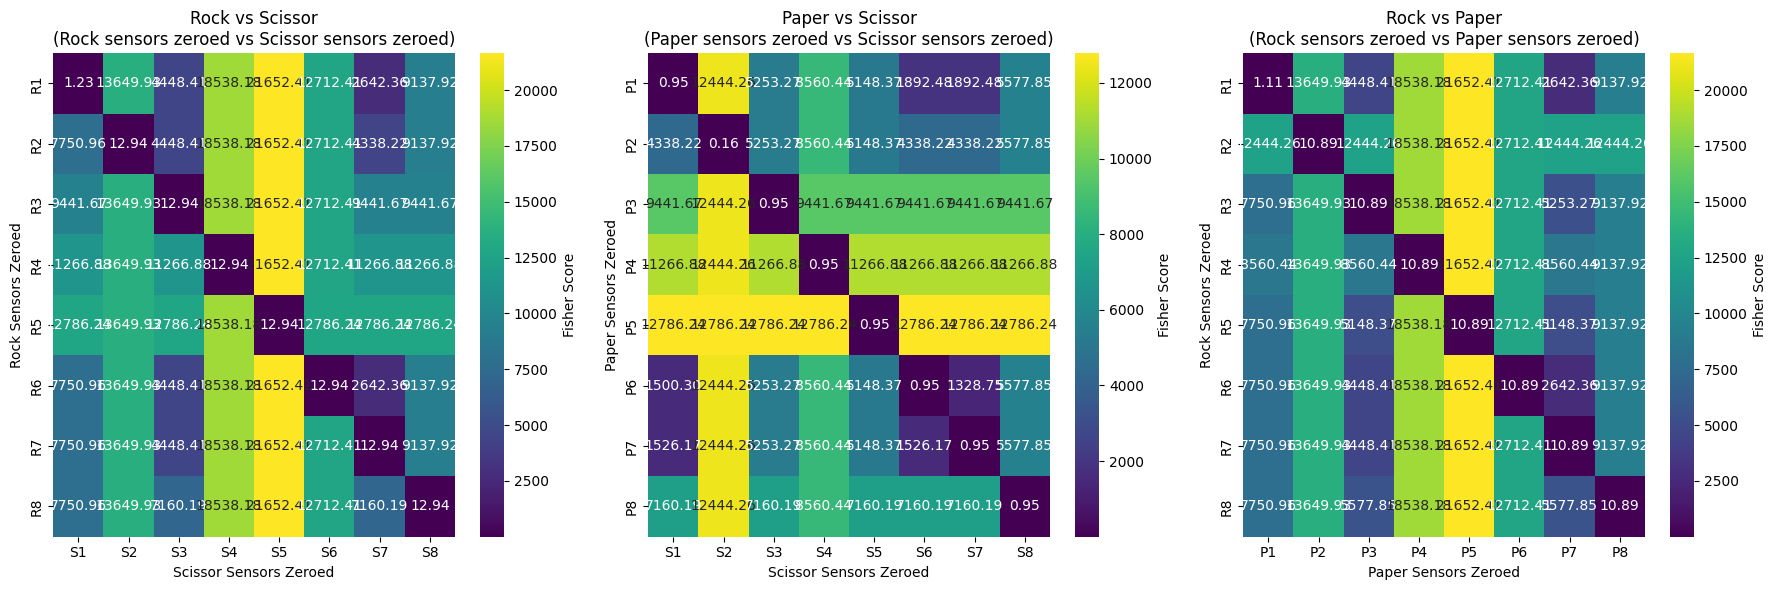

In [15]:
# Visualize the results with heatmaps
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Rock vs Scissor heatmap
sns.heatmap(rock_scissor_matrix, annot=True, fmt='.2f', cmap='viridis', 
            xticklabels=[f'S{j+1}' for j in range(8)], 
            yticklabels=[f'R{i+1}' for i in range(8)],
            ax=axes[0], cbar_kws={'label': 'Fisher Score'})
axes[0].set_title('Rock vs Scissor\n(Rock sensors zeroed vs Scissor sensors zeroed)')
axes[0].set_xlabel('Scissor Sensors Zeroed')
axes[0].set_ylabel('Rock Sensors Zeroed')

# Paper vs Scissor heatmap
sns.heatmap(paper_scissor_matrix, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=[f'S{j+1}' for j in range(8)], 
            yticklabels=[f'P{i+1}' for i in range(8)],
            ax=axes[1], cbar_kws={'label': 'Fisher Score'})
axes[1].set_title('Paper vs Scissor\n(Paper sensors zeroed vs Scissor sensors zeroed)')
axes[1].set_xlabel('Scissor Sensors Zeroed')
axes[1].set_ylabel('Paper Sensors Zeroed')

# Rock vs Paper heatmap
sns.heatmap(rock_paper_matrix, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=[f'P{j+1}' for j in range(8)], 
            yticklabels=[f'R{i+1}' for i in range(8)],
            ax=axes[2], cbar_kws={'label': 'Fisher Score'})
axes[2].set_title('Rock vs Paper\n(Rock sensors zeroed vs Paper sensors zeroed)')
axes[2].set_xlabel('Paper Sensors Zeroed')
axes[2].set_ylabel('Rock Sensors Zeroed')

plt.tight_layout()
plt.show()


In [16]:
# Summary analysis - Find most and least important sensors
def analyze_sensor_impact(result_matrix, class1_name, class2_name):
    """
    Analyze the impact of zeroing out sensors on classification performance
    """
    print(f"\n{'='*50}")
    print(f"SENSOR IMPACT ANALYSIS: {class1_name} vs {class2_name}")
    print(f"{'='*50}")
    
    # Find the minimum Fisher score (worst performance when sensors are zeroed)
    min_score = np.min(result_matrix)
    min_indices = np.where(result_matrix == min_score)
    
    # Find the maximum Fisher score (best performance when sensors are zeroed)
    max_score = np.max(result_matrix)
    max_indices = np.where(result_matrix == max_score)
    
    print(f"Lowest Fisher Score: {min_score:.4f}")
    print(f"  Occurs when zeroing:")
    for i, j in zip(min_indices[0], min_indices[1]):
        print(f"    {class1_name} sensor {i+1} and {class2_name} sensor {j+1}")
    
    print(f"\nHighest Fisher Score: {max_score:.4f}")
    print(f"  Occurs when zeroing:")
    for i, j in zip(max_indices[0], max_indices[1]):
        print(f"    {class1_name} sensor {i+1} and {class2_name} sensor {j+1}")
    
    # Calculate average impact per sensor
    class1_avg_impact = np.mean(result_matrix, axis=1)
    class2_avg_impact = np.mean(result_matrix, axis=0)
    
    print(f"\nAverage impact of zeroing each {class1_name} sensor:")
    for i, impact in enumerate(class1_avg_impact):
        print(f"  {class1_name} sensor {i+1}: {impact:.4f}")
    
    print(f"\nAverage impact of zeroing each {class2_name} sensor:")
    for i, impact in enumerate(class2_avg_impact):
        print(f"  {class2_name} sensor {i+1}: {impact:.4f}")
    
    return class1_avg_impact, class2_avg_impact

# Analyze all three comparisons
rock_scissor_impact = analyze_sensor_impact(rock_scissor_matrix, "Rock", "Scissor")
paper_scissor_impact = analyze_sensor_impact(paper_scissor_matrix, "Paper", "Scissor")
rock_paper_impact = analyze_sensor_impact(rock_paper_matrix, "Rock", "Paper")



SENSOR IMPACT ANALYSIS: Rock vs Scissor
Lowest Fisher Score: 1.2336
  Occurs when zeroing:
    Rock sensor 1 and Scissor sensor 1

Highest Fisher Score: 21652.4148
  Occurs when zeroing:
    Rock sensor 1 and Scissor sensor 5
    Rock sensor 2 and Scissor sensor 5
    Rock sensor 3 and Scissor sensor 5
    Rock sensor 4 and Scissor sensor 5
    Rock sensor 6 and Scissor sensor 5
    Rock sensor 7 and Scissor sensor 5
    Rock sensor 8 and Scissor sensor 5

Average impact of zeroing each Rock sensor:
  Rock sensor 1: 10347.8583
  Rock sensor 2: 9823.9321
  Rock sensor 3: 11861.3605
  Rock sensor 4: 11636.9031
  Rock sensor 5: 12016.5290
  Rock sensor 6: 9729.1404
  Rock sensor 7: 10987.8961
  Rock sensor 8: 11079.6530

Average impact of zeroing each Scissor sensor:
  Scissor sensor 1: 8062.4845
  Scissor sensor 2: 11945.3081
  Scissor sensor 3: 6127.4846
  Scissor sensor 4: 16222.5280
  Scissor sensor 5: 18947.4800
  Scissor sensor 6: 11134.2039
  Scissor sensor 7: 6286.3579
  Scissor 

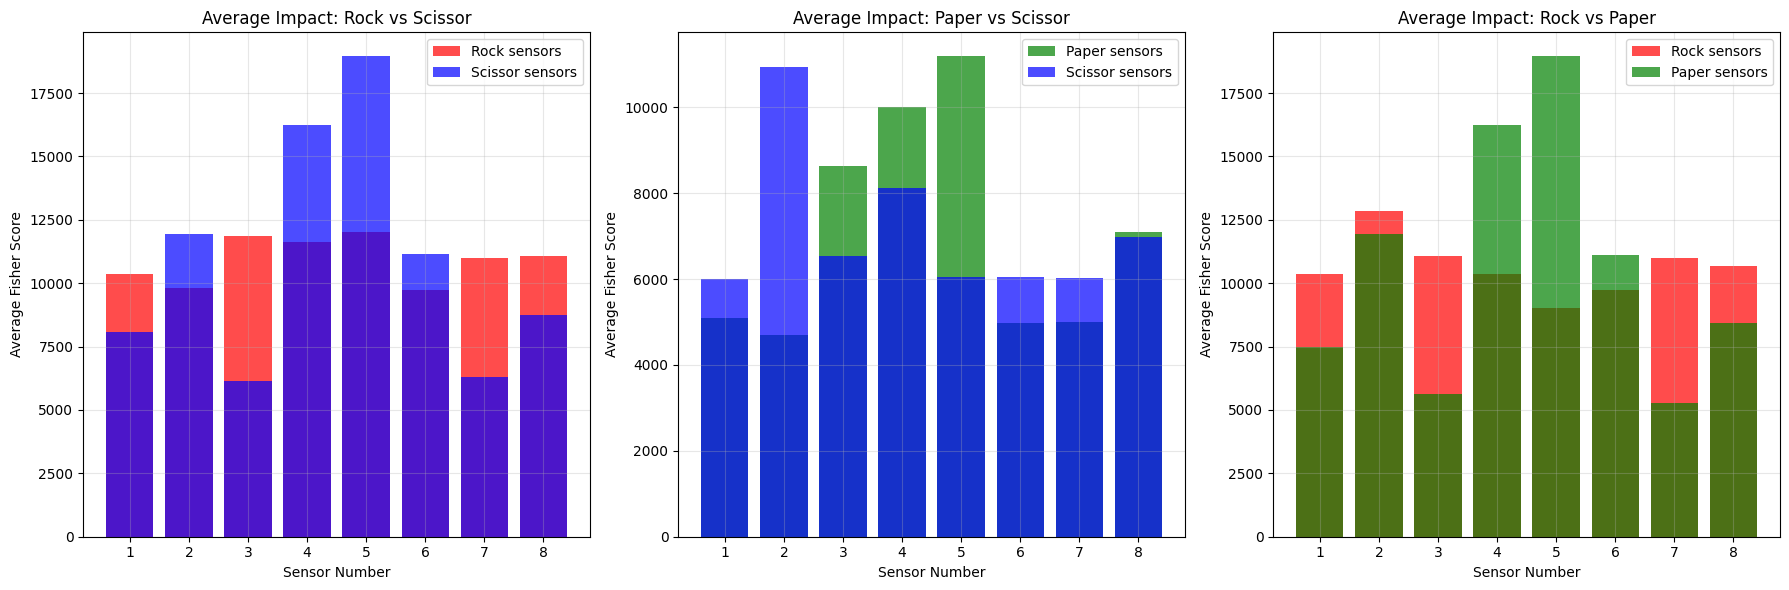


SUMMARY: SENSOR IMPORTANCE RANKING
Lower Fisher scores indicate more important sensors (more impact when zeroed)
Higher Fisher scores indicate less important sensors (less impact when zeroed)
  Sensor  Rock_vs_Scissor  Paper_vs_Scissor  Rock_vs_Paper  Overall_Avg
Sensor_6      9729.140392       4976.772542    9728.884409  8144.932448
Sensor_1     10347.858333       5096.261560   10347.843345  8597.321079
Sensor_7     10987.896142       5004.683605   10987.640160  8993.406636
Sensor_2      9823.932099       4694.342846   12836.365861  9118.213602
Sensor_8     11079.653044       7100.824688   10683.812248  9621.429993
Sensor_3     11861.360485       8636.901994   11088.247471 10528.836650
Sensor_4     11636.903058      10005.812433   10355.609448 10666.108313
Sensor_5     12016.529035      11188.074595    9012.129516 10738.911049


In [17]:
# Visualize average sensor impact
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Rock vs Scissor average impact
rock_avg, scissor_avg = rock_scissor_impact
axes[0].bar(range(1, 9), rock_avg, alpha=0.7, label='Rock sensors', color='red')
axes[0].bar(range(1, 9), scissor_avg, alpha=0.7, label='Scissor sensors', color='blue')
axes[0].set_title('Average Impact: Rock vs Scissor')
axes[0].set_xlabel('Sensor Number')
axes[0].set_ylabel('Average Fisher Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Paper vs Scissor average impact
paper_avg, scissor_avg2 = paper_scissor_impact
axes[1].bar(range(1, 9), paper_avg, alpha=0.7, label='Paper sensors', color='green')
axes[1].bar(range(1, 9), scissor_avg2, alpha=0.7, label='Scissor sensors', color='blue')
axes[1].set_title('Average Impact: Paper vs Scissor')
axes[1].set_xlabel('Sensor Number')
axes[1].set_ylabel('Average Fisher Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Rock vs Paper average impact
rock_avg2, paper_avg2 = rock_paper_impact
axes[2].bar(range(1, 9), rock_avg2, alpha=0.7, label='Rock sensors', color='red')
axes[2].bar(range(1, 9), paper_avg2, alpha=0.7, label='Paper sensors', color='green')
axes[2].set_title('Average Impact: Rock vs Paper')
axes[2].set_xlabel('Sensor Number')
axes[2].set_ylabel('Average Fisher Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*80)
print("SUMMARY: SENSOR IMPORTANCE RANKING")
print("="*80)
print("Lower Fisher scores indicate more important sensors (more impact when zeroed)")
print("Higher Fisher scores indicate less important sensors (less impact when zeroed)")
print("="*80)

# Create summary dataframe
import pandas as pd

summary_data = []
for i in range(8):
    summary_data.append({
        'Sensor': f'Sensor_{i+1}',
        'Rock_vs_Scissor': rock_scissor_impact[0][i],
        'Paper_vs_Scissor': paper_scissor_impact[0][i], 
        'Rock_vs_Paper': rock_paper_impact[0][i],
        'Overall_Avg': np.mean([rock_scissor_impact[0][i], paper_scissor_impact[0][i], rock_paper_impact[0][i]])
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Overall_Avg')
print(summary_df.to_string(index=False))
